## Below is the code to recreate Figure 9.

Topic: Showing the simulated M44 (via best-fit isochrone) against actual 2mass data (shows continuity between papers).

In [1]:
# Importing necessary packages.
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity
import numpy as np
import pandas as pd
import pylab as py
import pdb
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, vstack
%matplotlib inline
%load_ext autoreload
%autoreload

In [2]:
# Define isochrone parameters
logAge = 8.845 # Age in log(years)
AKs = 0.01 # extinction in mags
dist = 187 # distance in parsec
metallicity = 0 # Metallicity in [M/H]

# Define evolution/atmosphere models and extinction law
evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec() 
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()

# Also specify filters for synthetic photometry (optional). Here we use 
# the HST WFC3-IR F127M, F139M, and F153M filters
filt_list = ['2mass,J', '2mass,Ks', 'ps1,i', 'ps1,z', 'ps1,y']

# Specify the directory we want the output isochrone
# table saved in. If the directory does not already exist,
# SPISEA will create it.
iso_dir = 'isochrones/'

# Make IsochronePhot object. Note that this will take a minute or two, 
# unless the isochrone has been generated previously.
#
# Note that this is not show all of the user options 
# for IsochronePhot. See docs for complete list of options.
iso = synthetic.IsochronePhot(logAge, AKs, dist, metallicity=0,
                            evo_model=evo_model, atm_func=atm_func,
                            red_law=red_law, filters=filt_list,
                            iso_dir=iso_dir, recomp=True)

Changing to T=   250 for T=   206 logg=3.41
Changing to logg=5.00 for T=  2017 logg=5.29
Changing to logg=5.00 for T=  2046 logg=5.29
Changing to logg=5.00 for T=  2075 logg=5.30
Changing to logg=5.00 for T=  2104 logg=5.30
Changing to logg=5.00 for T=  2131 logg=5.30
Changing to logg=5.00 for T=  2158 logg=5.31
Changing to logg=5.00 for T=  2185 logg=5.31
Changing to logg=5.00 for T=  2214 logg=5.31
Changing to logg=5.00 for T=  2242 logg=5.31
Changing to logg=5.00 for T=  2271 logg=5.32
Changing to logg=5.00 for T=  2300 logg=5.32
Changing to logg=5.00 for T=  2330 logg=5.32
Changing to logg=5.00 for T=  2330 logg=5.32
Isochrone generation took 12.527270 s.
Making photometry for isochrone: log(t) = 8.85  AKs = 0.01  dist = 187
     Starting at:  2026-04-17 10:30:49.238432   Usually takes ~5 minutes
Starting filter: 2mass,J   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.001 Msun  T =   206 K  m_2mass_J = 36.27
M =   0.400 Msun  T =  3344 K  m_2mass_J = 13.76
M =   

In [3]:
other = '/System/Volumes/Data/mnt/g3/scratch/caitlinbegbie/code/SPISEA/docs/paper_examples/Begbie+26/cluster_data/apj491325t1_mrt.txt'
tab = Table.read(other, format='ascii')
tab

Num,RAdeg,DEdeg,pmRA,e_pmRA,pmDE,e_pmDE,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,ymag,e_ymag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,Flag,Name
,deg,deg,mas / yr,mas / yr,mas / yr,mas / yr,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str11
1,127.20262,18.976639,-35.6,5.6,-15.0,5.6,20.39,0.03,19.04,0.01,17.17,0.0,16.4,0.0,15.93,0.01,14.73,0.02,14.08,0.07,13.75,0.01,0,--
2,127.20794,19.988964,-37.5,4.2,-17.1,4.2,16.88,0.0,15.15,0.6,14.42,0.6,14.05,0.0,13.61,0.0,12.34,0.02,11.73,0.02,11.46,0.02,0,--
3,127.26084,19.636719,-38.2,4.2,-5.8,4.2,18.71,0.01,17.39,0.0,16.42,0.0,99.0,99.0,99.0,99.0,14.63,0.03,14.05,0.04,13.8,0.04,0,--
4,127.30614,19.479976,-36.8,1.3,-15.4,1.3,11.6,0.6,11.2,0.6,11.03,0.6,10.96,0.6,10.93,0.6,10.02,0.02,9.73,0.02,9.65,0.02,0,--
5,127.32851,20.717992,-41.9,4.1,-17.3,4.1,17.65,0.0,16.47,0.0,15.27,0.0,14.72,0.0,14.47,0.0,13.28,0.02,12.66,0.02,12.4,0.02,0,--
6,127.42774,20.952028,-33.3,4.1,-15.5,4.1,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,13.34,0.02,12.73,0.03,12.5,0.02,0,--
7,127.43485,20.673132,-38.7,1.3,-12.6,1.3,12.44,0.0,15.72,0.0,12.16,0.0,11.43,0.0,11.35,0.0,10.35,0.02,9.91,0.03,9.81,0.02,1,--
8,127.46176,18.399097,-28.2,4.2,-14.9,4.2,21.56,0.05,20.14,0.03,18.24,0.01,17.35,0.0,16.91,0.01,15.57,0.07,15.12,0.09,14.59,0.08,0,--


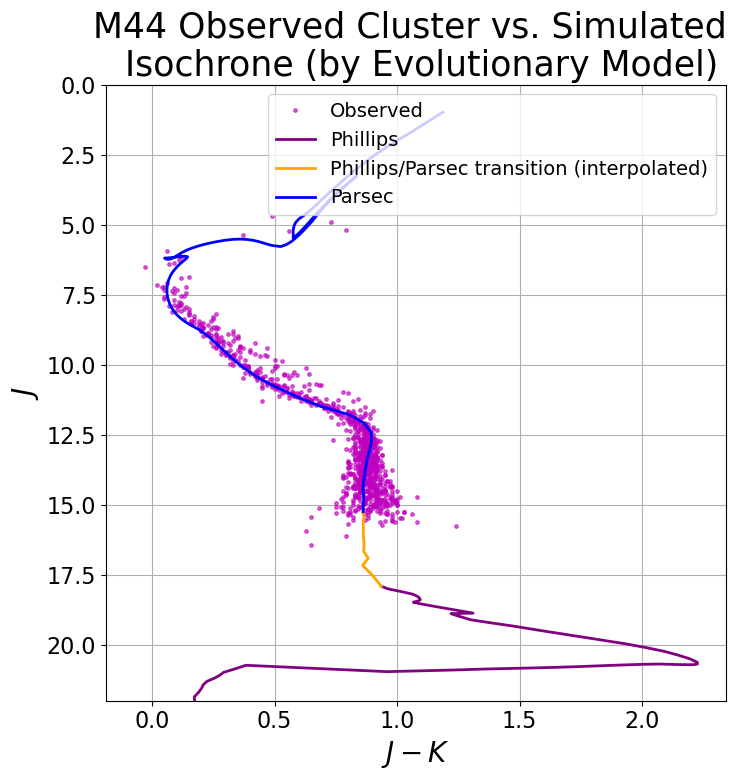

In [5]:
# Make a color-magnitude diagram from the isochrone
m = iso.points['mass']
J_iso = iso.points['m_2mass_J']
K_iso = iso.points['m_2mass_Ks']

phillips = (m >= 0.01) & (m < 0.0755)
phillips_parsec = (m >= 0.075) & (m < 0.2)

parsec = (m >= 0.2)

#focus = np.where((tab['Jmag'] - tab['K2mag'] < 10))
#minus = tab['Jmag'] - tab['K2mag']
#J_K = minus[focus]

py.figure(1, figsize=(8,8))
py.clf()
color = J_iso - K_iso
mag   = J_iso
py.plot(tab['Jmag'] - tab['Kmag'], tab['Jmag'],
            'm.', ms=5, alpha=0.6, label='Observed')
py.plot(color[phillips], mag[phillips], '-', lw=2, color='purple', label='Phillips')
py.plot(color[phillips_parsec], mag[phillips_parsec], '-', lw=2, color='orange', label='Phillips/Parsec transition (interpolated)')
py.plot(color[parsec], mag[parsec], '-', lw=2, color='blue', label='Parsec')

py.title('M44 Observed Cluster vs. Simulated \n Isochrone (by Evolutionary Model)', fontsize=25)
py.xlabel('$J - K$', fontsize=20)
py.ylabel('$J$', fontsize=20)
py.ylim(0, 22)
py.gca().invert_yaxis()
py.grid()
py.legend(loc='upper right', fontsize=14)
py.tick_params(axis='both', labelsize=16)
#py.savefig('M44_comparison.png')
py.show()